# 02 逻辑回归：sigmoid、交叉熵与二分类

目标：用一个 GitHub 上的小型二分类数据集，完成逻辑回归的完整学习流程。

本实验只把框架搭好，几个关键参数需要你自己填写：

- `TEST_SIZE`
- `LEARNING_RATE`
- `EPOCHS`
- `THRESHOLD`

数据集：Pima Indians Diabetes Dataset。任务是根据 8 个身体指标预测是否患糖尿病，标签 `Outcome` 为 `0` 或 `1`。

## 1. 导入依赖

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

np.random.seed(42)
plt.rcParams["figure.figsize"] = (7, 4)

## 2. 读取 GitHub 数据集

这个 CSV 没有表头，所以我们手动给每一列命名。最后一列 `Outcome` 是标签：

- `0`：没有糖尿病
- `1`：有糖尿病

In [60]:
DATA_URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome",
]

df = pd.read_csv(DATA_URL, names=columns)

print("Shape:", df.shape)
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 3. 快速查看数据

先看每一列的数据类型、是否有缺失值，以及标签分布。

In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [62]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


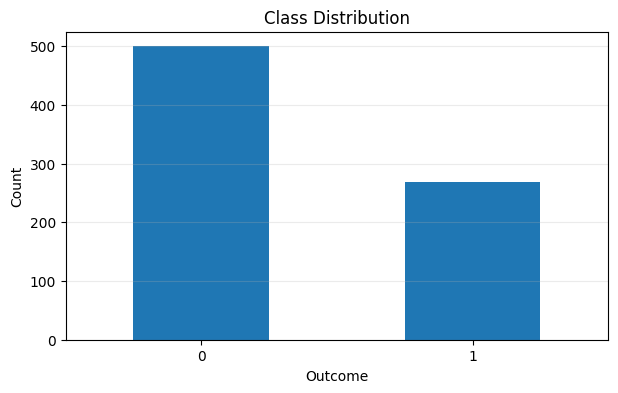

In [63]:
df["Outcome"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.25)
plt.show()

## 4. 准备特征和标签

`X` 是输入特征，`y` 是二分类标签。

In [64]:
X = df.drop(columns="Outcome").to_numpy(dtype=float)
y = df["Outcome"].to_numpy(dtype=float)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("First 5 labels:", y[:5])

X shape: (768, 8)
y shape: (768,)
First 5 labels: [1. 0. 1. 0. 1.]


## 5. 划分训练集和测试集

请你填写 `TEST_SIZE`。

提示：常见选择是 `0.2` 或 `0.25`。

In [65]:
TEST_SIZE = 0.2  # TODO: 你来填，例如 0.2

assert TEST_SIZE is not None, "请先填写 TEST_SIZE，例如 0.2"

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=42,
    stratify=y,
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train mean:", y_train.mean())
print("y_test mean:", y_test.mean())

X_train: (614, 8)
X_test: (154, 8)
y_train mean: 0.3485342019543974
y_test mean: 0.35064935064935066


## 6. 特征标准化

逻辑回归也依赖梯度下降。不同特征尺度差距很大时，训练会变慢，所以这里先做标准化。

注意：只能用训练集拟合 scaler，再用同一个 scaler 变换测试集。

In [66]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Before scaling, train mean of first feature:", X_train[:, 0].mean())
print("After scaling, train mean of first feature:", X_train_scaled[:, 0].mean())

Before scaling, train mean of first feature: 3.8192182410423454
After scaling, train mean of first feature: -5.207560766971418e-17


## 7. sigmoid 函数

逻辑回归先计算：

$$z = Xw + b$$

再通过 sigmoid 把任意实数压到 `0~1`：

$$\sigma(z)=\frac{1}{1+e^{-z}}$$

这个输出可以理解成属于正类 `1` 的概率。

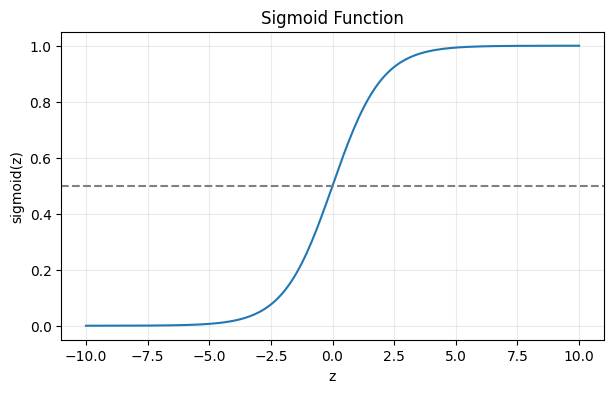

In [67]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))


z_values = np.linspace(-10, 10, 200)
plt.plot(z_values, sigmoid(z_values))
plt.axhline(0.5, color="gray", linestyle="--")
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.title("Sigmoid Function")
plt.grid(alpha=0.25)
plt.show()

## 8. 手写逻辑回归函数

这里先把核心函数写好。你重点理解：

- `linear_output = X @ w + b`
- `probability = sigmoid(linear_output)`
- 交叉熵损失衡量概率预测和真实标签的差距

In [68]:
def predict_proba(X, w, b):
    linear_output = X @ w + b
    return sigmoid(linear_output)


def compute_binary_cross_entropy(X, y, w, b):
    eps = 1e-12
    p = predict_proba(X, w, b)
    p = np.clip(p, eps, 1 - eps)
    loss = -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))
    return loss


def compute_gradients(X, y, w, b):
    m = len(y)
    p = predict_proba(X, w, b)
    error = p - y

    dw = (X.T @ error) / m
    db = np.sum(error) / m
    return dw, db


def gradient_descent(X, y, learning_rate, epochs):
    n_features = X.shape[1]
    w = np.zeros(n_features)
    b = 0.0
    history = []

    for epoch in range(epochs):
        loss = compute_binary_cross_entropy(X, y, w, b)
        history.append(loss)

        dw, db = compute_gradients(X, y, w, b)
        w = w - learning_rate * dw
        b = b - learning_rate * db

    return w, b, history

## 9. 训练手写逻辑回归

请你填写 `LEARNING_RATE` 和 `EPOCHS`。

提示：标准化后可以先试 `0.01`、`0.05`、`0.1`。训练轮数可以先试 `1000`。

In [80]:
LEARNING_RATE = 0.05  # TODO: 你来填，例如 0.05
EPOCHS = 10000        # TODO: 你来填，例如 1000

assert LEARNING_RATE is not None, "请先填写 LEARNING_RATE，例如 0.05"
assert EPOCHS is not None, "请先填写 EPOCHS，例如 1000"

w, b, history = gradient_descent(
    X_train_scaled,
    y_train,
    learning_rate=LEARNING_RATE,
    epochs=EPOCHS,
)

print("w shape:", w.shape)
print("b:", b)
print("final train loss:", history[-1])

w shape: (8,)
b: -0.8806650817286852
final train loss: 0.4662068566239556


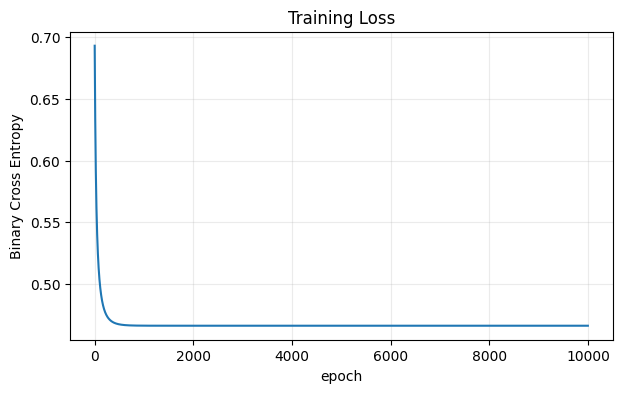

In [81]:
plt.plot(history)
plt.xlabel("epoch")
plt.ylabel("Binary Cross Entropy")
plt.title("Training Loss")
plt.grid(alpha=0.25)
plt.show()

## 10. 概率转成类别

逻辑回归输出的是概率。要得到类别，需要设置阈值。

请你填写 `THRESHOLD`。

提示：二分类最常见的起点是 `0.5`。

In [86]:
THRESHOLD = 0.5  # TODO: 你来填，例如 0.5

assert THRESHOLD is not None, "请先填写 THRESHOLD，例如 0.5"

def predict_class(X, w, b, threshold):
    probabilities = predict_proba(X, w, b)
    return (probabilities >= threshold).astype(int)


manual_train_pred = predict_class(X_train_scaled, w, b, THRESHOLD)
manual_test_pred = predict_class(X_test_scaled, w, b, THRESHOLD)

manual_train_accuracy = accuracy_score(y_train, manual_train_pred)
manual_test_accuracy = accuracy_score(y_test, manual_test_pred)

print(f"Manual train accuracy: {manual_train_accuracy:.4f}")
print(f"Manual test accuracy:  {manual_test_accuracy:.4f}")

Manual train accuracy: 0.7948
Manual test accuracy:  0.7143


## 11. 评估手写模型

In [83]:
print("Confusion matrix:")
print(confusion_matrix(y_test, manual_test_pred))

print("\nClassification report:")
print(classification_report(y_test, manual_test_pred))

Confusion matrix:
[[82 18]
 [26 28]]

Classification report:
              precision    recall  f1-score   support

         0.0       0.76      0.82      0.79       100
         1.0       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



## 12. 对比 sklearn LogisticRegression

In [78]:
sklearn_model = LogisticRegression(max_iter=1000)
sklearn_model.fit(X_train_scaled, y_train)

sklearn_test_pred = sklearn_model.predict(X_test_scaled)
sklearn_test_accuracy = accuracy_score(y_test, sklearn_test_pred)

print(f"Manual test accuracy:  {manual_test_accuracy:.4f}")
print(f"sklearn test accuracy: {sklearn_test_accuracy:.4f}")

Manual test accuracy:  0.7143
sklearn test accuracy: 0.7143


In [79]:
print("sklearn confusion matrix:")
print(confusion_matrix(y_test, sklearn_test_pred))

print("\nsklearn classification report:")
print(classification_report(y_test, sklearn_test_pred))

sklearn confusion matrix:
[[82 18]
 [26 28]]

sklearn classification report:
              precision    recall  f1-score   support

         0.0       0.76      0.82      0.79       100
         1.0       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



## 13. 总结

请你完成下面的问题：

1. 逻辑回归和线性回归的共同点是什么？
2. 为什么逻辑回归要加 sigmoid？
3. 为什么这个实验用交叉熵，而不是 MSE？
4. `THRESHOLD` 改变后，预测结果会发生什么？
5. 手写模型和 sklearn 结果是否一样？可能是什么原因？

我的总结：

- 本次实验是一个二分类任务：根据 Pima Indians Diabetes 数据集中 8 个身体指标，预测 `Outcome` 是 `0` 还是 `1`。它和线性回归一样，都会先计算一个线性组合 `z = Xw + b`；区别是逻辑回归会再接一个 sigmoid，把 `z` 变成 `0~1` 之间的概率，所以它适合做分类。
- 这个实验使用交叉熵而不是 MSE，因为标签是类别 `0/1`，模型输出的是“属于正类的概率”。交叉熵会惩罚模型对真实类别给出很低概率的情况，更适合分类问题。MSE 更适合预测连续数值的回归问题。
- 当前手写逻辑回归已经基本跑通。早期 `LEARNING_RATE=0.001`、`EPOCHS=1000` 时训练不够充分，loss 还比较高；后来增加训练轮数并调整学习率后，最终训练 loss 约为 `0.4662`，训练集准确率约 `79.48%`，测试集准确率约 `71.43%`，和 sklearn 的测试准确率一致。
- 当继续增加 epoch 后准确率不再明显提升，说明当前逻辑回归模型基本收敛了。此时限制不再主要是训练次数，而是模型表达能力、数据噪声、特征质量和阈值选择。逻辑回归本质上是线性分类器，如果特征之间存在复杂非线性关系，可能需要决策树、随机森林或后续的神经网络来建模。
- `THRESHOLD` 会影响预测为 `0` 或 `1` 的比例。测试中 `0.4` 和 `0.6` 的 accuracy 都不如 `0.5`，说明在当前模型和测试集上，`0.5` 对 accuracy 最合适。但在医疗场景中不能只看 accuracy，还要关注假阴性和假阳性，尤其是漏诊风险。